In [2]:
!pip install pandas


   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ----------------- ---------------------- 4.7/11.0 MB 26.0 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 28.1 MB/s  0:00:00

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 

----Impact of adding e1e2 in c_{kl} metric-----
First let us plot the mean, sigma and the efficiency  with/without the e1e2 added in c_{kl} metric.

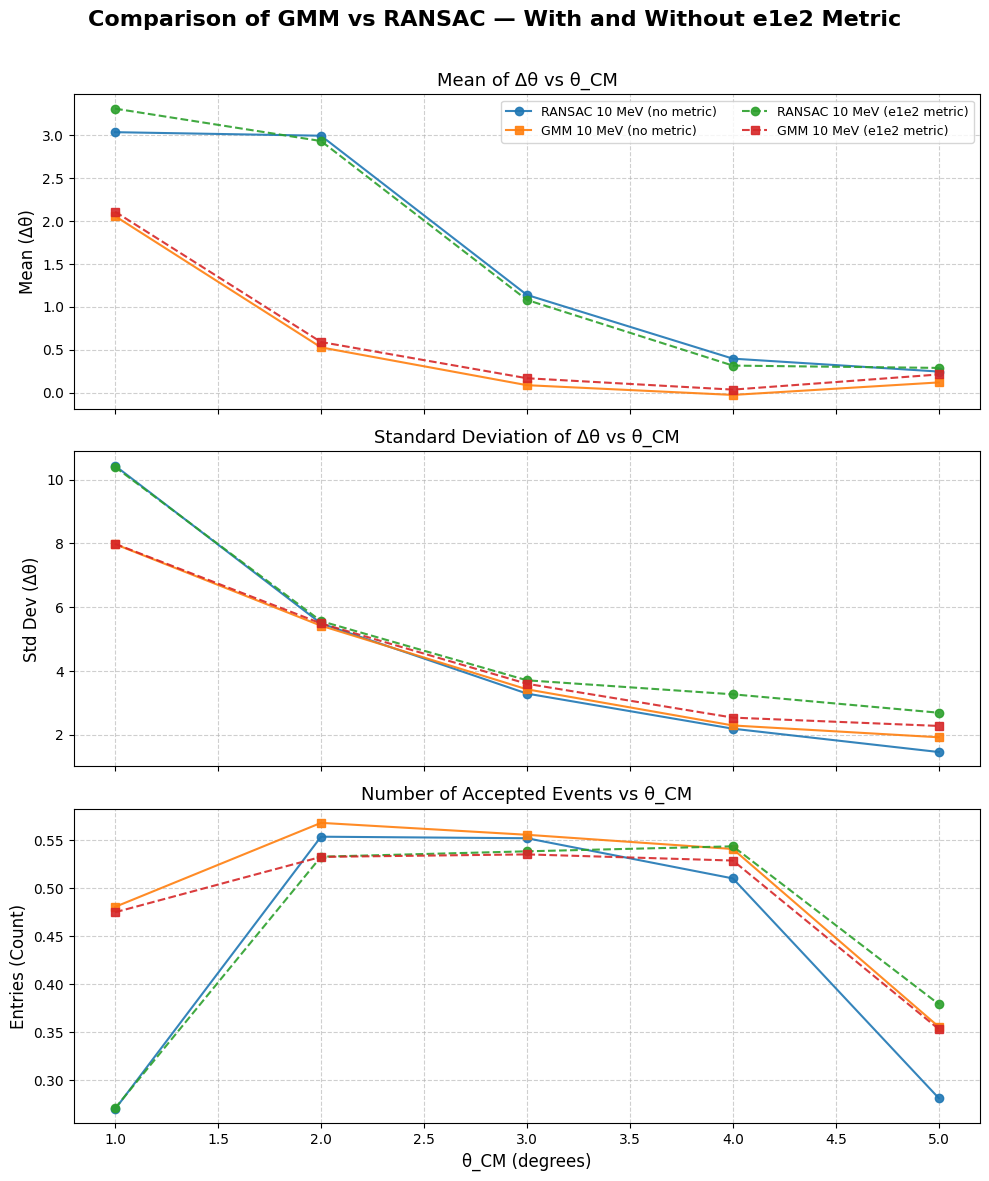

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# === Load both datasets ===
data_no = np.load("list_metrice1e2no.npy", allow_pickle=True)
data_metric = np.load("list_e1e2metric.npy", allow_pickle=True)

# Convert to arrays
data_no = np.array(data_no)
data_metric = np.array(data_metric)

# Helper function to extract components
def extract_components(data):
    return {
        "energy": data[:, 0],
        "cm": data[:, 1],
        "suppress": data[:, 2],
        "ransac_entries": data[:, 3],
        "ransac_mean": data[:, 4],
        "ransac_std": data[:, 5],
        "gmm_entries": data[:, 6],
        "gmm_mean": data[:, 7],
        "gmm_std": data[:, 8],
    }

d_no = extract_components(data_no)
d_metric = extract_components(data_metric)

unique_energies = np.unique(d_no["energy"])

# === Create plots ===
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig.suptitle("Comparison of GMM vs RANSAC — With and Without e1e2 Metric", fontsize=16, fontweight='bold')

# Define line styles for clarity
styles = {
    "no": {"linestyle": "-", "alpha": 0.9},
    "metric": {"linestyle": "--", "alpha": 0.9}
}

# === Subplot 1: Mean ===
for e in unique_energies:
    mask_no = d_no["energy"] == e
    mask_metric = d_metric["energy"] == e

    # No metric
    axes[0].plot(d_no["cm"][mask_no], d_no["ransac_mean"][mask_no], marker='o', **styles["no"], label=f'RANSAC {int(e)} MeV (no metric)')
    axes[0].plot(d_no["cm"][mask_no], d_no["gmm_mean"][mask_no], marker='s', **styles["no"], label=f'GMM {int(e)} MeV (no metric)')
    # With metric
    axes[0].plot(d_metric["cm"][mask_metric], d_metric["ransac_mean"][mask_metric], marker='o', **styles["metric"], label=f'RANSAC {int(e)} MeV (e1e2 metric)')
    axes[0].plot(d_metric["cm"][mask_metric], d_metric["gmm_mean"][mask_metric], marker='s', **styles["metric"], label=f'GMM {int(e)} MeV (e1e2 metric)')

axes[0].set_ylabel("Mean (Δθ)", fontsize=12)
axes[0].set_title("Mean of Δθ vs θ_CM", fontsize=13)
axes[0].legend(fontsize=9, ncol=2)
axes[0].grid(True, linestyle='--', alpha=0.6)

# === Subplot 2: Std Dev ===
for e in unique_energies:
    mask_no = d_no["energy"] == e
    mask_metric = d_metric["energy"] == e

    axes[1].plot(d_no["cm"][mask_no], d_no["ransac_std"][mask_no], marker='o', **styles["no"], label=f'RANSAC {int(e)} MeV (no metric)')
    axes[1].plot(d_no["cm"][mask_no], d_no["gmm_std"][mask_no], marker='s', **styles["no"], label=f'GMM {int(e)} MeV (no metric)')
    axes[1].plot(d_metric["cm"][mask_metric], d_metric["ransac_std"][mask_metric], marker='o', **styles["metric"], label=f'RANSAC {int(e)} MeV (e1e2 metric)')
    axes[1].plot(d_metric["cm"][mask_metric], d_metric["gmm_std"][mask_metric], marker='s', **styles["metric"], label=f'GMM {int(e)} MeV (e1e2 metric)')

axes[1].set_ylabel("Std Dev (Δθ)", fontsize=12)
axes[1].set_title("Standard Deviation of Δθ vs θ_CM", fontsize=13)
axes[1].grid(True, linestyle='--', alpha=0.6)

# === Subplot 3: Entries ===
for e in unique_energies:
    mask_no = d_no["energy"] == e
    mask_metric = d_metric["energy"] == e

    axes[2].plot(d_no["cm"][mask_no], d_no["ransac_entries"][mask_no]/5000, marker='o', **styles["no"], label=f'RANSAC {int(e)} MeV (no metric)')
    axes[2].plot(d_no["cm"][mask_no], d_no["gmm_entries"][mask_no]/5000, marker='s', **styles["no"], label=f'GMM {int(e)} MeV (no metric)')
    axes[2].plot(d_metric["cm"][mask_metric], d_metric["ransac_entries"][mask_metric]/5000, marker='o', **styles["metric"], label=f'RANSAC {int(e)} MeV (e1e2 metric)')
    axes[2].plot(d_metric["cm"][mask_metric], d_metric["gmm_entries"][mask_metric]/5000, marker='s', **styles["metric"], label=f'GMM {int(e)} MeV (e1e2 metric)')

axes[2].set_xlabel("θ_CM (degrees)", fontsize=12)
axes[2].set_ylabel("Entries (Count)", fontsize=12)
axes[2].set_title("Number of Accepted Events vs θ_CM", fontsize=13)
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


Observations: At 1 degree in the center of the mass angles, the gain due to GMM is preserved (regardless). At 5 degrees however, the scenario flips: without the e1e2 addition in c_{kl}, GMM had more statistics than RANSAC. With the addition of e1e2 in the c_{kl} RANSAC has approximately 2 percent higher statistics than GMM. 

Let us look into the 5 degree cm case without e1e2 addition in c_{kl} and look at the reasons for rejection

===== RANSAC: Rejection Reason Counts =====
                                                                         combined_reasons  num_events
                                                                              end_outside        1254
                                                                        more_than_1_track         977
                                                                    phi_cut + end_outside         536
                                                                           no_track_found         249
                                                                                  phi_cut         239
                                                            start_outside + inter_outside          58
                                              start_outside + end_outside + inter_outside          35
                                                              start_outside + end_outside          26
                                      

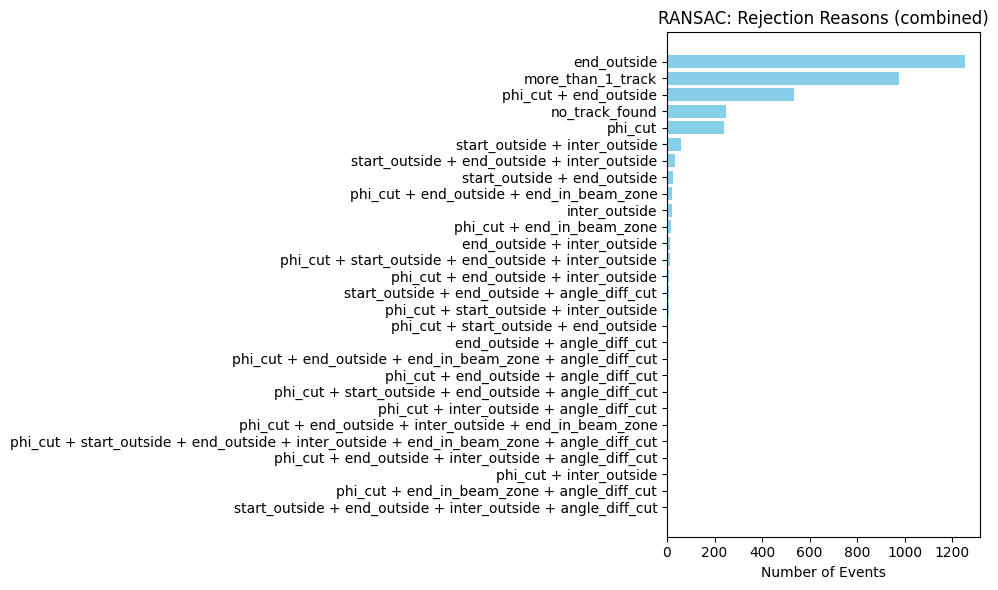

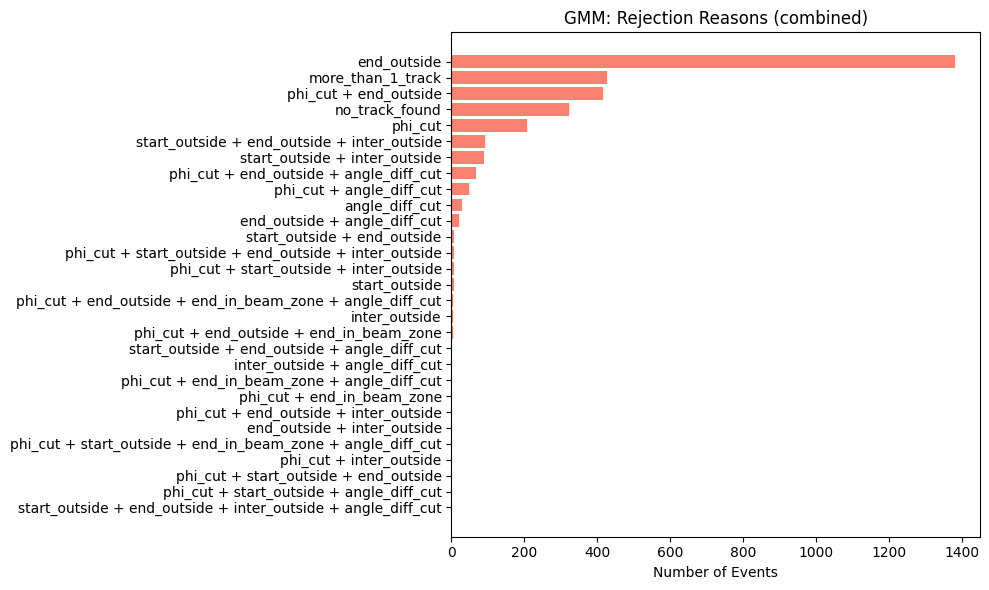

In [21]:
# -----------------------------
# Jupyter Notebook: Rejection Visualization
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
csv_file = "filter_rejections_gmm_ransac_5cm_e1e2metricno.csv"

filter_names = [
    "no_track_found",
    "more_than_1_track",
    "phi_cut",
    "start_outside",
    "end_outside",
    "inter_outside",
    "end_in_beam_zone",
    "angle_diff_cut"
]

# -----------------------------
# Load CSV
# -----------------------------
df = pd.read_csv(csv_file)

# -----------------------------
# Separate by method
# -----------------------------
df_ransac = df[df['method'] == 'RANSAC'].copy()
df_gmm = df[df['method'] == 'GMM'].copy()

# -----------------------------
# Combine rejection reasons per event
# -----------------------------
def get_combined_reasons(row):
    reasons = [f for f in filter_names if row[f]]
    return " + ".join(reasons) if reasons else "Accepted"

df_ransac['combined_reasons'] = df_ransac.apply(get_combined_reasons, axis=1)
df_gmm['combined_reasons'] = df_gmm.apply(get_combined_reasons, axis=1)

# -----------------------------
# Count events per combined reason
# -----------------------------
ransac_counts = df_ransac['combined_reasons'].value_counts().reset_index()
ransac_counts.columns = ['combined_reasons', 'num_events']

gmm_counts = df_gmm['combined_reasons'].value_counts().reset_index()
gmm_counts.columns = ['combined_reasons', 'num_events']

# -----------------------------
# Print counts for inspection
# -----------------------------
print("===== RANSAC: Rejection Reason Counts =====")
print(ransac_counts.to_string(index=False))
print("\n===== GMM: Rejection Reason Counts =====")
print(gmm_counts.to_string(index=False))

# -----------------------------
# Plot: RANSAC
# -----------------------------
plt.figure(figsize=(10,6))
plt.barh(ransac_counts['combined_reasons'], ransac_counts['num_events'], color='skyblue')
plt.xlabel("Number of Events")
plt.title("RANSAC: Rejection Reasons (combined)")
plt.gca().invert_yaxis()  # Highest count on top
plt.tight_layout()
plt.show()

# -----------------------------
# Plot: GMM
# -----------------------------
plt.figure(figsize=(10,6))
plt.barh(gmm_counts['combined_reasons'], gmm_counts['num_events'], color='salmon')
plt.xlabel("Number of Events")
plt.title("GMM: Rejection Reasons (combined)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


===== RANSAC: Rejection Reason Counts =====
                                                                         combined_reasons  num_events
                                                                              end_outside        1429
                                                                    phi_cut + end_outside         615
                                                                                  phi_cut         269
                                                                           no_track_found         257
                                                                        more_than_1_track         123
                                                            start_outside + inter_outside          78
                                              start_outside + end_outside + inter_outside          46
                                                              start_outside + end_outside          26
                                      

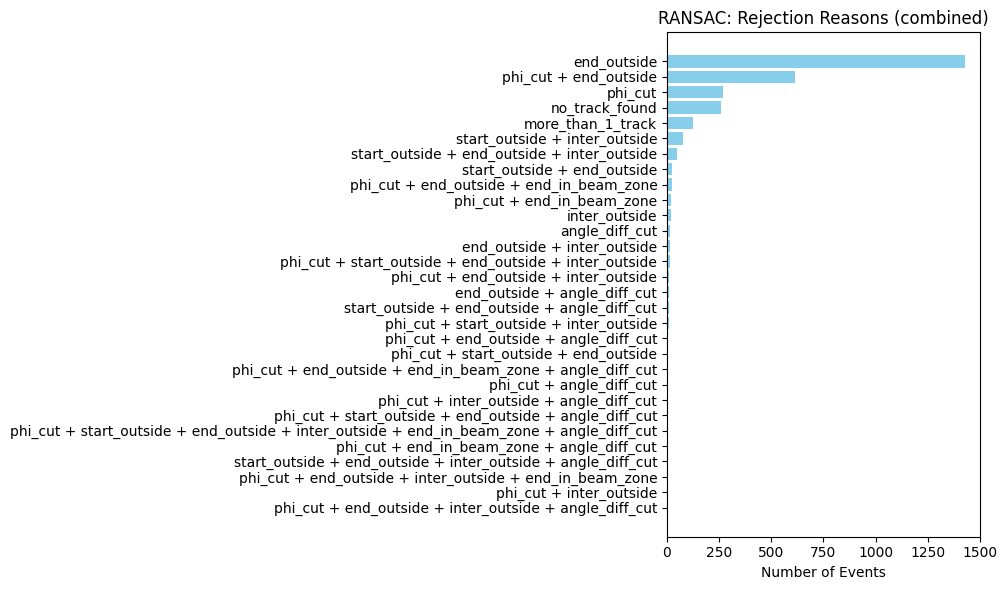

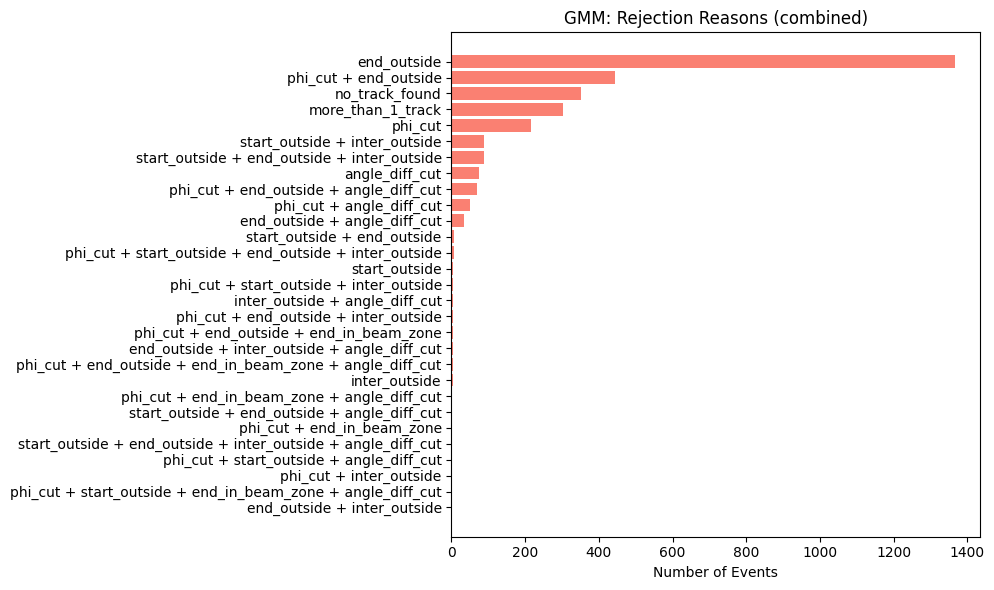

In [22]:
# -----------------------------
# Jupyter Notebook: Rejection Visualization
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
csv_file = "filter_rejections_gmm_ransac_5cm_e1e2metric.csv"

filter_names = [
    "no_track_found",
    "more_than_1_track",
    "phi_cut",
    "start_outside",
    "end_outside",
    "inter_outside",
    "end_in_beam_zone",
    "angle_diff_cut"
]

# -----------------------------
# Load CSV
# -----------------------------
df = pd.read_csv(csv_file)

# -----------------------------
# Separate by method
# -----------------------------
df_ransac = df[df['method'] == 'RANSAC'].copy()
df_gmm = df[df['method'] == 'GMM'].copy()

# -----------------------------
# Combine rejection reasons per event
# -----------------------------
def get_combined_reasons(row):
    reasons = [f for f in filter_names if row[f]]
    return " + ".join(reasons) if reasons else "Accepted"

df_ransac['combined_reasons'] = df_ransac.apply(get_combined_reasons, axis=1)
df_gmm['combined_reasons'] = df_gmm.apply(get_combined_reasons, axis=1)

# -----------------------------
# Count events per combined reason
# -----------------------------
ransac_counts = df_ransac['combined_reasons'].value_counts().reset_index()
ransac_counts.columns = ['combined_reasons', 'num_events']

gmm_counts = df_gmm['combined_reasons'].value_counts().reset_index()
gmm_counts.columns = ['combined_reasons', 'num_events']

# -----------------------------
# Print counts for inspection
# -----------------------------
print("===== RANSAC: Rejection Reason Counts =====")
print(ransac_counts.to_string(index=False))
print("\n===== GMM: Rejection Reason Counts =====")
print(gmm_counts.to_string(index=False))

# -----------------------------
# Plot: RANSAC
# -----------------------------
plt.figure(figsize=(10,6))
plt.barh(ransac_counts['combined_reasons'], ransac_counts['num_events'], color='skyblue')
plt.xlabel("Number of Events")
plt.title("RANSAC: Rejection Reasons (combined)")
plt.gca().invert_yaxis()  # Highest count on top
plt.tight_layout()
plt.show()

# -----------------------------
# Plot: GMM
# -----------------------------
plt.figure(figsize=(10,6))
plt.barh(gmm_counts['combined_reasons'], gmm_counts['num_events'], color='salmon')
plt.xlabel("Number of Events")
plt.title("GMM: Rejection Reasons (combined)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



===== RANSAC: Comparison =====
                                                                         combined_reasons  num_events_without  num_events_with  delta
                                                                              end_outside              1254.0             1429  175.0
                                                                    phi_cut + end_outside               536.0              615   79.0
                                                                                  phi_cut               239.0              269   30.0
                                                                           no_track_found               249.0              257    8.0
                                                                        more_than_1_track               977.0              123 -854.0
                                                            start_outside + inter_outside                58.0               78   20.0
                              

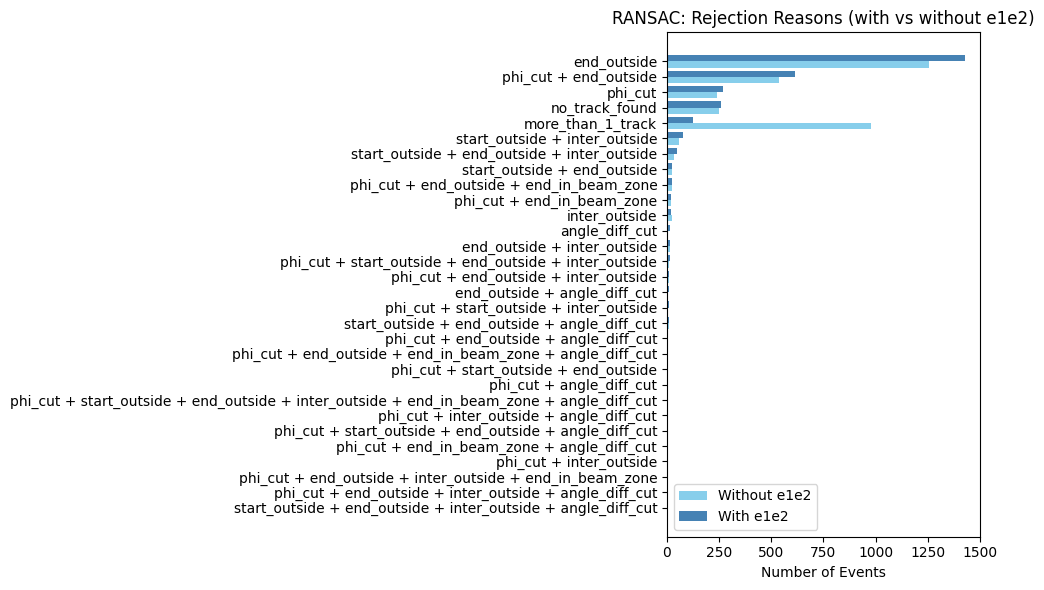

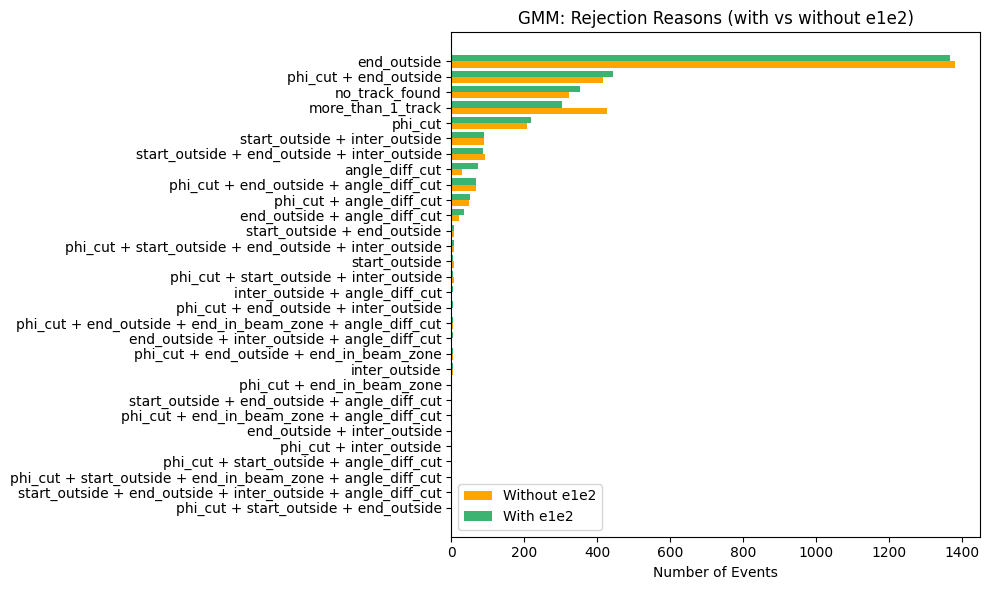

In [24]:
# -----------------------------
# Jupyter Notebook: Rejection Comparison (with vs without e1e2)
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
csv_with = "filter_rejections_gmm_ransac_5cm_e1e2metric.csv"
csv_without = "filter_rejections_gmm_ransac_5cm_e1e2metricno.csv"

filter_names = [
    "no_track_found",
    "more_than_1_track",
    "phi_cut",
    "start_outside",
    "end_outside",
    "inter_outside",
    "end_in_beam_zone",
    "angle_diff_cut"
]

# -----------------------------
# Function to load and process one CSV
# -----------------------------
def load_and_process(csv_file):
    df = pd.read_csv(csv_file)
    df_ransac = df[df['method'] == 'RANSAC'].copy()
    df_gmm = df[df['method'] == 'GMM'].copy()

    def get_combined_reasons(row):
        reasons = [f for f in filter_names if row[f]]
        return " + ".join(reasons) if reasons else "Accepted"

    df_ransac['combined_reasons'] = df_ransac.apply(get_combined_reasons, axis=1)
    df_gmm['combined_reasons'] = df_gmm.apply(get_combined_reasons, axis=1)

    ransac_counts = df_ransac['combined_reasons'].value_counts().reset_index()
    ransac_counts.columns = ['combined_reasons', 'num_events']

    gmm_counts = df_gmm['combined_reasons'].value_counts().reset_index()
    gmm_counts.columns = ['combined_reasons', 'num_events']

    return ransac_counts, gmm_counts

# -----------------------------
# Load both datasets
# -----------------------------
ransac_with, gmm_with = load_and_process(csv_with)
ransac_without, gmm_without = load_and_process(csv_without)

# -----------------------------
# Merge for comparison
# -----------------------------
def merge_counts(df_without, df_with, label):
    merged = pd.merge(df_without, df_with, on="combined_reasons", how="outer", suffixes=('_without', '_with')).fillna(0)
    merged['delta'] = merged['num_events_with'] - merged['num_events_without']
    merged = merged.sort_values('num_events_with', ascending=False)
    print(f"\n===== {label}: Comparison =====")
    print(merged.to_string(index=False))
    return merged

merged_ransac = merge_counts(ransac_without, ransac_with, "RANSAC")
merged_gmm = merge_counts(gmm_without, gmm_with, "GMM")

# -----------------------------
# Plot function
# -----------------------------
def plot_comparison(df, title, color1, color2):
    plt.figure(figsize=(10,6))
    y = range(len(df))
    plt.barh([i+0.2 for i in y], df['num_events_without'], height=0.4, color=color1, label="Without e1e2")
    plt.barh([i-0.2 for i in y], df['num_events_with'], height=0.4, color=color2, label="With e1e2")
    plt.yticks(y, df['combined_reasons'])
    plt.xlabel("Number of Events")
    plt.title(title)
    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# -----------------------------
# Plot: RANSAC
# -----------------------------
plot_comparison(
    merged_ransac,
    "RANSAC: Rejection Reasons (with vs without e1e2)",
    color1="skyblue",    # Without e1e2
    color2="steelblue"   # With e1e2
)

# -----------------------------
# Plot: GMM
# -----------------------------
plot_comparison(
    merged_gmm,
    "GMM: Rejection Reasons (with vs without e1e2)",
    color1="orange",     # Without e1e2
    color2="mediumseagreen"  # With e1e2
)


RANSAC: Total=3009, Accepted=0, Rejected=3009
GMM   : Total=3139, Accepted=0, Rejected=3139


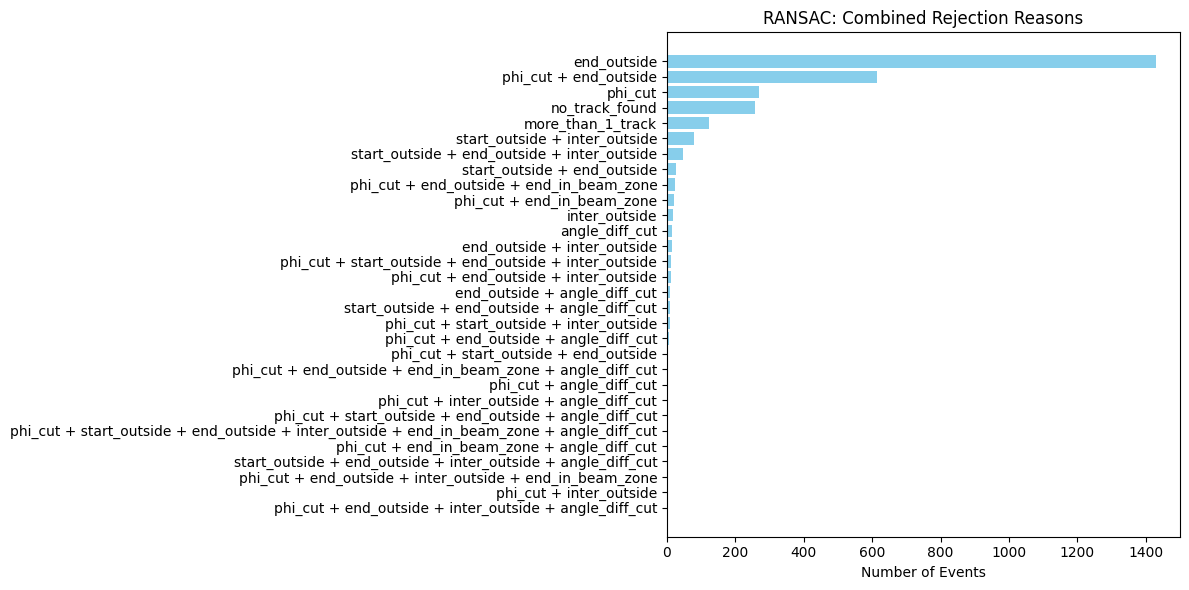

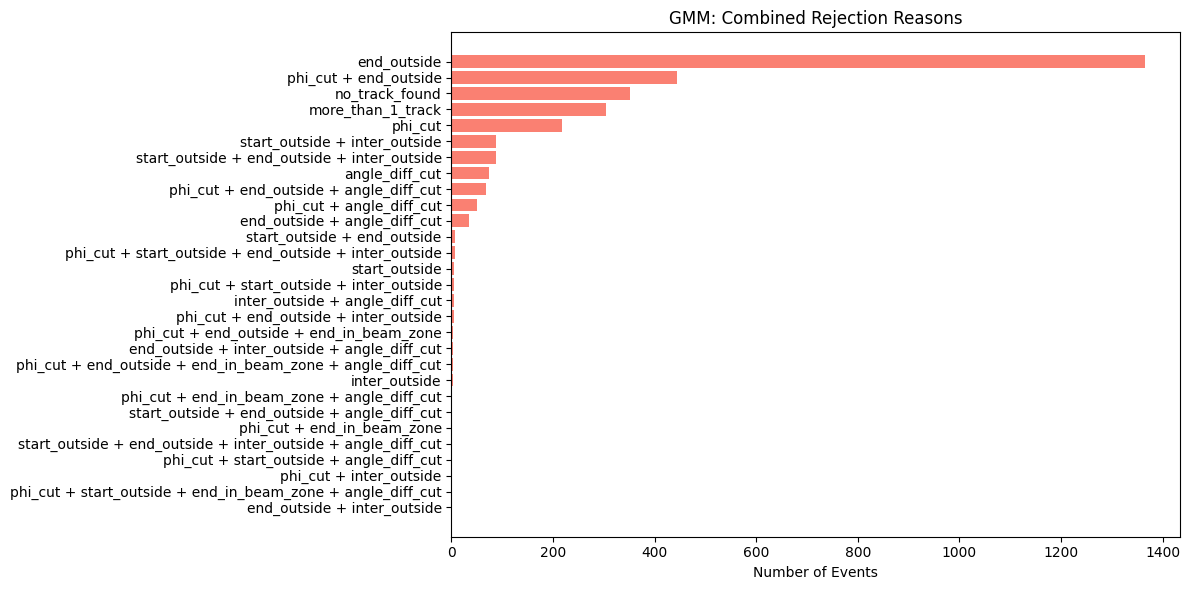

In [8]:
# -----------------------------
# Jupyter Cell: Rejection Visualization with Event Counts
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt

# Make sure CSV is already loaded
# df_ransac, df_gmm exist and filter_names are defined

# -----------------------------
# Compute accepted/rejected events
# -----------------------------
df_ransac['accepted'] = ~df_ransac[filter_names].any(axis=1)
df_gmm['accepted'] = ~df_gmm[filter_names].any(axis=1)

# Total events
total_ransac = len(df_ransac)
total_gmm = len(df_gmm)

# Accepted events
accepted_ransac = df_ransac['accepted'].sum()
accepted_gmm = df_gmm['accepted'].sum()

# Rejected events
rejected_ransac = total_ransac - accepted_ransac
rejected_gmm = total_gmm - accepted_gmm

# -----------------------------
# Print summary
# -----------------------------
print(f"RANSAC: Total={total_ransac}, Accepted={accepted_ransac}, Rejected={rejected_ransac}")
print(f"GMM   : Total={total_gmm}, Accepted={accepted_gmm}, Rejected={rejected_gmm}")

# -----------------------------
# Combine rejection reasons for plotting
# -----------------------------
def get_combined_reasons(row):
    reasons = [f for f in filter_names if row[f]]
    return " + ".join(reasons) if reasons else "Accepted"

df_ransac['combined_reasons'] = df_ransac.apply(get_combined_reasons, axis=1)
df_gmm['combined_reasons'] = df_gmm.apply(get_combined_reasons, axis=1)

# -----------------------------
# Count number of events per combined reason
# -----------------------------
ransac_counts = df_ransac['combined_reasons'].value_counts().reset_index()
ransac_counts.columns = ['combined_reasons', 'num_events']

gmm_counts = df_gmm['combined_reasons'].value_counts().reset_index()
gmm_counts.columns = ['combined_reasons', 'num_events']

# -----------------------------
# Plot: RANSAC
# -----------------------------
plt.figure(figsize=(12,6))
plt.barh(ransac_counts['combined_reasons'], ransac_counts['num_events'], color='skyblue')
plt.xlabel("Number of Events")
plt.title("RANSAC: Combined Rejection Reasons")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot: GMM
# -----------------------------
plt.figure(figsize=(12,6))
plt.barh(gmm_counts['combined_reasons'], gmm_counts['num_events'], color='salmon')
plt.xlabel("Number of Events")
plt.title("GMM: Combined Rejection Reasons")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


GMM rejected 3139 events
RANSAC rejected 3009 events
Extra rejections unique to GMM: 230
Extra rejections unique to RANSAC: 100

Top individual reasons for extra GMM rejections:
more_than_1_track    127
angle_diff_cut        72
end_outside           11
no_track_found        10
phi_cut               10
inter_outside          5
start_outside          3
end_in_beam_zone       0
dtype: int64


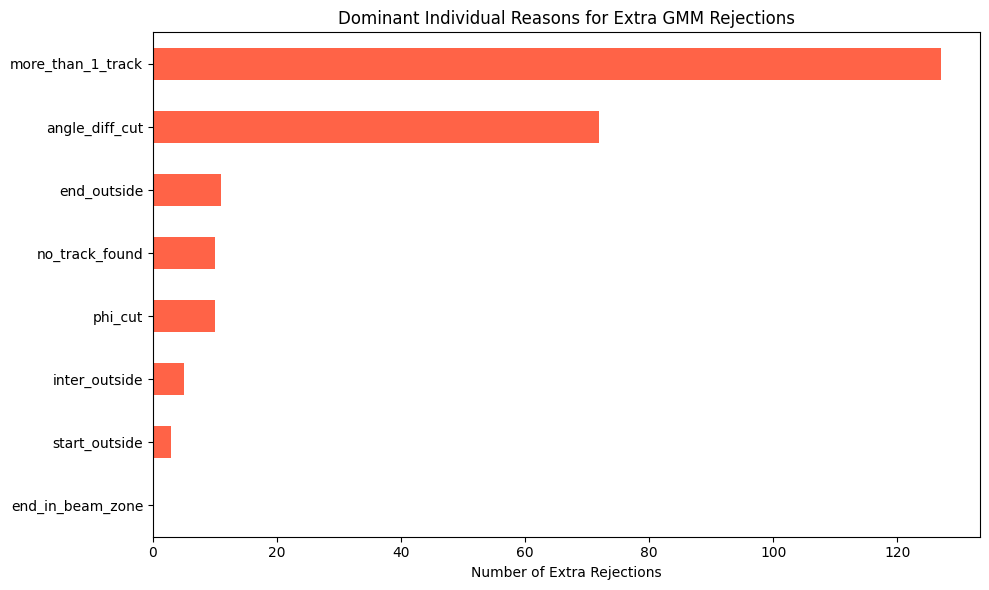

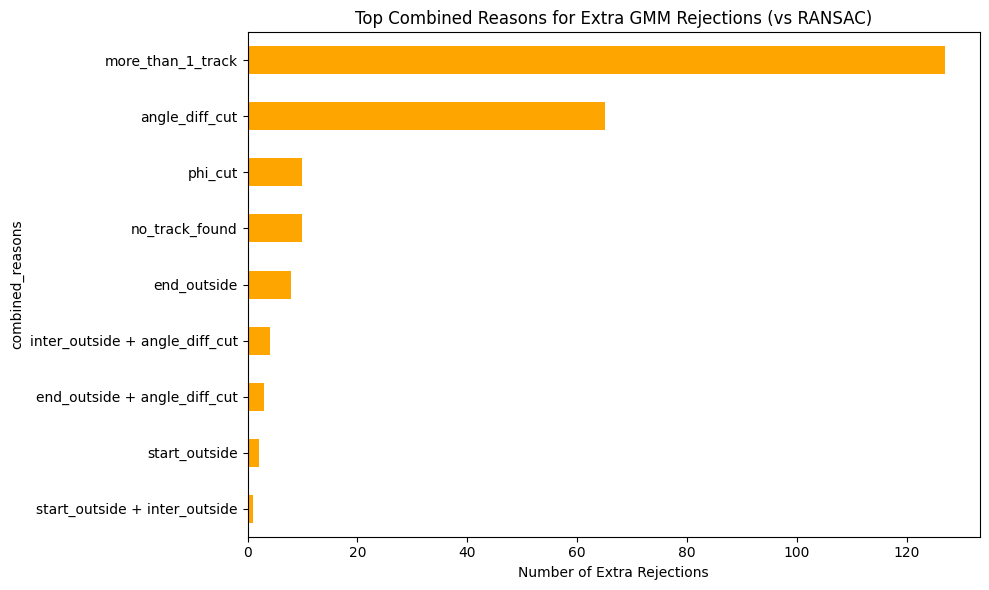

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("filter_rejections_gmm_ransac_5cm_e1e2metric.csv")

filter_names = [
    "no_track_found", "more_than_1_track", "phi_cut",
    "start_outside", "end_outside", "inter_outside",
    "end_in_beam_zone", "angle_diff_cut"
]

# Split methods
df_ransac = df[df["method"] == "RANSAC"].copy()
df_gmm = df[df["method"] == "GMM"].copy()

# Get sets of rejected event IDs
ransac_rejected = set(df_ransac["event_id"])
gmm_rejected = set(df_gmm["event_id"])

extra_gmm_rejected_ids = gmm_rejected - ransac_rejected
extra_ransac_rejected_ids = ransac_rejected - gmm_rejected

print(f"GMM rejected {len(gmm_rejected)} events")
print(f"RANSAC rejected {len(ransac_rejected)} events")
print(f"Extra rejections unique to GMM: {len(extra_gmm_rejected_ids)}")
print(f"Extra rejections unique to RANSAC: {len(extra_ransac_rejected_ids)}")

# Filter those extra GMM-rejected events
extra_gmm_df = df_gmm[df_gmm["event_id"].isin(extra_gmm_rejected_ids)].copy()

# --- Count individual reasons ---
reason_counts = extra_gmm_df[filter_names].sum().sort_values(ascending=False)

# --- Combination of reasons ---
def combine_reasons(row):
    return " + ".join([r for r in filter_names if row[r]])

extra_gmm_df["combined_reasons"] = extra_gmm_df.apply(combine_reasons, axis=1)
combo_counts = extra_gmm_df["combined_reasons"].value_counts().head(10)

print("\nTop individual reasons for extra GMM rejections:")
print(reason_counts)

# --- Plot individual reasons ---
plt.figure(figsize=(10, 6))
reason_counts.plot(kind="barh", color="tomato")
plt.gca().invert_yaxis()
plt.title("Dominant Individual Reasons for Extra GMM Rejections")
plt.xlabel("Number of Extra Rejections")
plt.tight_layout()
plt.show()

# --- Plot combined reasons ---
plt.figure(figsize=(10, 6))
combo_counts.plot(kind="barh", color="orange")
plt.gca().invert_yaxis()
plt.title("Top Combined Reasons for Extra GMM Rejections (vs RANSAC)")
plt.xlabel("Number of Extra Rejections")
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd

# --- Load the CSV ---
df_all = pd.read_csv("filter_rejections_gmm_ransac_5cm_e1e2metric.csv")

# --- Define rejection reason columns ---
filter_names = [
    "no_track_found",
    "more_than_1_track",
    "phi_cut",
    "start_outside",
    "end_outside",
    "inter_outside",
    "end_in_beam_zone",
    "angle_diff_cut"
]

# --- Separate data for GMM and RANSAC ---
df_gmm = df_all[df_all["method"] == "GMM"].copy()
df_ransac = df_all[df_all["method"] == "RANSAC"].copy()

# --- Find rejected event IDs ---
gmm_rejected = set(df_gmm["event_id"])
ransac_rejected = set(df_ransac["event_id"])

extra_gmm = gmm_rejected - ransac_rejected
extra_ransac = ransac_rejected - gmm_rejected

print(f"GMM rejected {len(gmm_rejected)} events")
print(f"RANSAC rejected {len(ransac_rejected)} events")
print(f"Extra GMM rejections: {len(extra_gmm)}")
print(f"Extra RANSAC rejections: {len(extra_ransac)}")
print()

# --- Function to summarize reasons ---
def summarize_reasons(df_subset):
    combo_counts = {}
    for _, row in df_subset.iterrows():
        active_reasons = tuple(sorted([r for r in filter_names if row[r]]))
        combo_counts[active_reasons] = combo_counts.get(active_reasons, 0) + 1
    return combo_counts

# --- Summaries ---
extra_gmm_df = df_gmm[df_gmm["event_id"].isin(extra_gmm)]
extra_ransac_df = df_ransac[df_ransac["event_id"].isin(extra_ransac)]

gmm_summary = summarize_reasons(extra_gmm_df)
ransac_summary = summarize_reasons(extra_ransac_df)

# --- Convert to DataFrames for easy viewing ---
gmm_summary_df = pd.DataFrame([
    {"Combination": ", ".join(k) if k else "None", "Count": v}
    for k, v in sorted(gmm_summary.items(), key=lambda x: x[1], reverse=True)
])

ransac_summary_df = pd.DataFrame([
    {"Combination": ", ".join(k) if k else "None", "Count": v}
    for k, v in sorted(ransac_summary.items(), key=lambda x: x[1], reverse=True)
])

print("=== Top GMM-only Rejection Reasons ===")
display(gmm_summary_df.head(10))

print("\n=== Top RANSAC-only Rejection Reasons ===")
display(ransac_summary_df.head(10))



GMM rejected 3139 events
RANSAC rejected 3009 events
Extra GMM rejections: 230
Extra RANSAC rejections: 100

=== Top GMM-only Rejection Reasons ===


,Combination,Count
0,more_than_1_track,127
1,angle_diff_cut,65
2,phi_cut,10
3,no_track_found,10
4,end_outside,8
5,"angle_diff_cut, inter_outside",4
6,"angle_diff_cut, end_outside",3
7,start_outside,2
8,"inter_outside, start_outside",1



=== Top RANSAC-only Rejection Reasons ===


,Combination,Count
0,more_than_1_track,59
1,end_outside,12
2,angle_diff_cut,11
3,phi_cut,9
4,no_track_found,3
5,inter_outside,2
6,"end_outside, phi_cut",2
7,"angle_diff_cut, phi_cut",1
8,"inter_outside, start_outside",1


In [12]:
import pandas as pd

# Load CSV
df = pd.read_csv("filter_rejections_gmm_ransac_5cm_e1e2metric.csv")

# Filter columns of interest
reason_cols = ["more_than_1_track", "angle_diff_cut"]

# Get rejected events per method
rejected_gmm = df[df["method"] == "GMM"]
rejected_ransac = df[df["method"] == "RANSAC"]

# Event ID sets
gmm_ids = set(rejected_gmm["event_id"])
ransac_ids = set(rejected_ransac["event_id"])

# Extra GMM rejections = rejected by GMM but not by RANSAC
extra_gmm_ids = gmm_ids - ransac_ids
extra_gmm_df = rejected_gmm[rejected_gmm["event_id"].isin(extra_gmm_ids)]

# --- Filter by specific reasons ---
for reason in reason_cols:
    reason_df = extra_gmm_df[extra_gmm_df[reason] == True]
    print(f"\n=== Extra GMM rejections due to '{reason}' ===")
    print(reason_df["event_id"].to_list())
    print(f"Total: {len(reason_df)} events")




=== Extra GMM rejections due to 'more_than_1_track' ===
[1257, 1272, 1277, 1323, 1367, 1376, 1440, 1477, 1487, 1049, 1070, 1141, 1171, 1245, 1248, 282, 311, 329, 347, 367, 385, 449, 499, 2538, 2552, 2588, 2590, 2592, 2614, 2652, 2733, 2741, 2751, 2773, 2860, 2911, 2915, 2959, 3270, 3302, 3344, 3413, 3469, 3492, 3155, 3177, 3199, 3206, 3222, 3232, 3234, 515, 517, 531, 616, 624, 644, 672, 679, 695, 733, 744, 746, 69, 135, 206, 4317, 4401, 4407, 4437, 4478, 4018, 4038, 4054, 4124, 4204, 4217, 1763, 1862, 928, 936, 1507, 1533, 1694, 2301, 2352, 2435, 2493, 2001, 2008, 2030, 2032, 2069, 2070, 2124, 2172, 2188, 3505, 3508, 3514, 3629, 3641, 3650, 3669, 3708, 3718, 3744, 3758, 3765, 3787, 3795, 3829, 3908, 3962, 4506, 4524, 4530, 4572, 4599, 4666, 4678, 4681, 4775, 4788, 4872, 4893, 4917]
Total: 127 events

=== Extra GMM rejections due to 'angle_diff_cut' ===
[1297, 1341, 1483, 1079, 1109, 1177, 1185, 1213, 403, 457, 2518, 2679, 2683, 2743, 2769, 2840, 2957, 2975, 3298, 3325, 3339, 3359, 336